# Metrics + Data Viz for Qwen/Gemma NER & LID

In [2]:
#Necessary imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [3]:
DATASET = "../output/qwen_ner_2026-07-12_18-13-01.csv" 
df = pd.read_csv(DATASET)

In [23]:
df.head()

,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,qwen_ner
0,0,post_0001,1,0,yabancı,TR,NaN,NaN,O
1,1,post_0001,1,1,bir,TR,NaN,NaN,O
2,2,post_0001,1,2,hocamızın,TR,NaN,NaN,O
3,3,post_0001,1,3,yarı,TR,NaN,NaN,O
4,4,post_0001,1,4,şaka,TR,NaN,NaN,O


In [27]:
#Sanity check
df["qwen_ner"].value_counts()

qwen_ner
O          4457
B-PROD      105
I-PROD       49
B-ORG        49
B-TITLE      40
I-TITLE      35
B-TIME       21
B-PER        18
I-ORG        16
B-OTHER      15
B-LOC        14
I-PER        12
B-GROUP       6
I-TIME        3
I-OTHER       2
B-EVENT       2
I-GROUP       2
I-LOC         1
I-EVENT       1
Name: count, dtype: int64

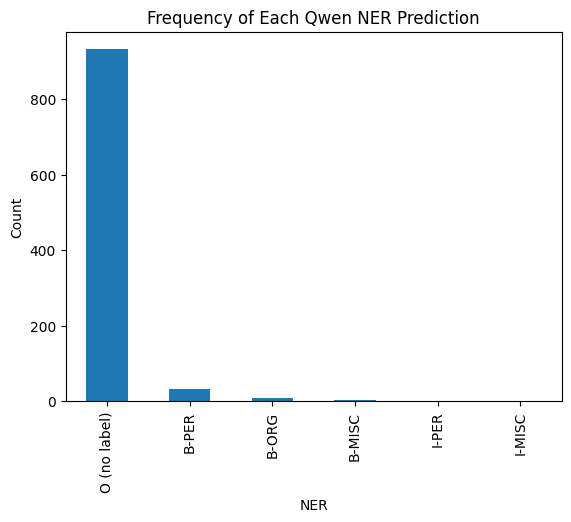

In [127]:
#Frequency of predictions
df['qwen_ner'].value_counts().plot(kind='bar')
plt.title('Frequency of Each Qwen NER Prediction')
plt.xlabel('NER')
plt.ylabel('Count')
plt.show()

In [32]:
df.dropna(subset=["qwen_ner"], inplace=True)

Unnamed: 0            0
doc_id                0
sent_id               0
tok_id                0
token                 0
lid                   0
borrowed_suffix    4706
ner                   0
qwen_ner              0
dtype: int64

In [31]:
df["ner"] = df["ner"].fillna("O")

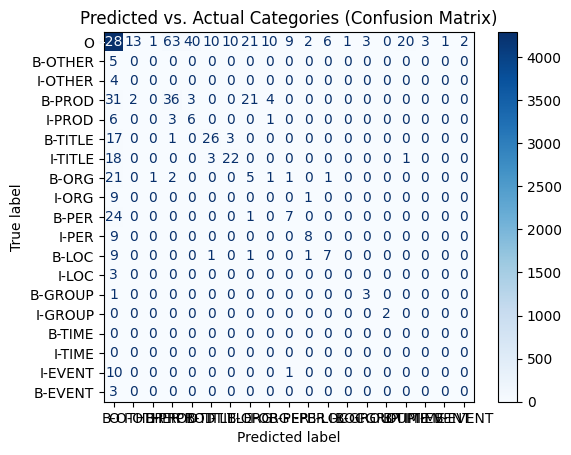

In [33]:
#Confusion matrix
cm = confusion_matrix(df['ner'], df['qwen_ner'], labels=["O", "B-OTHER", "I-OTHER", "B-PROD",
"I-PROD", "B-TITLE", "I-TITLE", "B-ORG", "I-ORG", "B-PER", "I-PER", 
"B-LOC", "I-LOC","B-GROUP", "I-GROUP",
"B-TIME", "I-TIME", "I-EVENT",
"B-EVENT", "UNK"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["O", "B-OTHER", "I-OTHER", "B-PROD",
"I-PROD", "B-TITLE", "I-TITLE", "B-ORG", "I-ORG", "B-PER", "I-PER", 
"B-LOC", "I-LOC","B-GROUP", "I-GROUP",
"B-TIME", "I-TIME", "I-EVENT",
"B-EVENT", "UNK"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs. Actual Categories (Confusion Matrix)")
plt.show()

In [34]:
#Macro F1
macro_f1 = f1_score(df["ner"], df["qwen_ner"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.2964



In [35]:
#F1 Per Class
f1_per_class = f1_score(df["ner"], df["qwen_ner"], average=None)
print(f"F1 Score per Class: {f1_per_class}\n")

F1 Score per Class: [0.         0.6        0.42424242 0.12345679 0.         0.28
 0.35643564 0.         0.59770115 0.         1.         0.
 0.         0.         0.55172414 0.18461538 0.         0.55696203
 0.95702645]



In [36]:
#Full Classification Report
print("Classification Report:")
print(classification_report(df["ner"], df["qwen_ner"]))

Classification Report:
              precision    recall  f1-score   support

     B-EVENT       0.00      0.00      0.00         3
     B-GROUP       0.50      0.75      0.60         4
       B-LOC       0.50      0.37      0.42        19
       B-ORG       0.10      0.16      0.12        32
     B-OTHER       0.00      0.00      0.00         5
       B-PER       0.39      0.22      0.28        32
      B-PROD       0.34      0.37      0.36        97
      B-TIME       0.00      0.00      0.00         0
     B-TITLE       0.65      0.55      0.60        47
     I-EVENT       0.00      0.00      0.00        11
     I-GROUP       1.00      1.00      1.00         2
       I-LOC       0.00      0.00      0.00         3
       I-ORG       0.00      0.00      0.00        10
     I-OTHER       0.00      0.00      0.00         4
       I-PER       0.67      0.47      0.55        17
      I-PROD       0.12      0.38      0.18        16
      I-TIME       0.00      0.00      0.00         0
    

/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

In [132]:
mismatched_rows = df[df['ner'] != df['qwen_ner']]

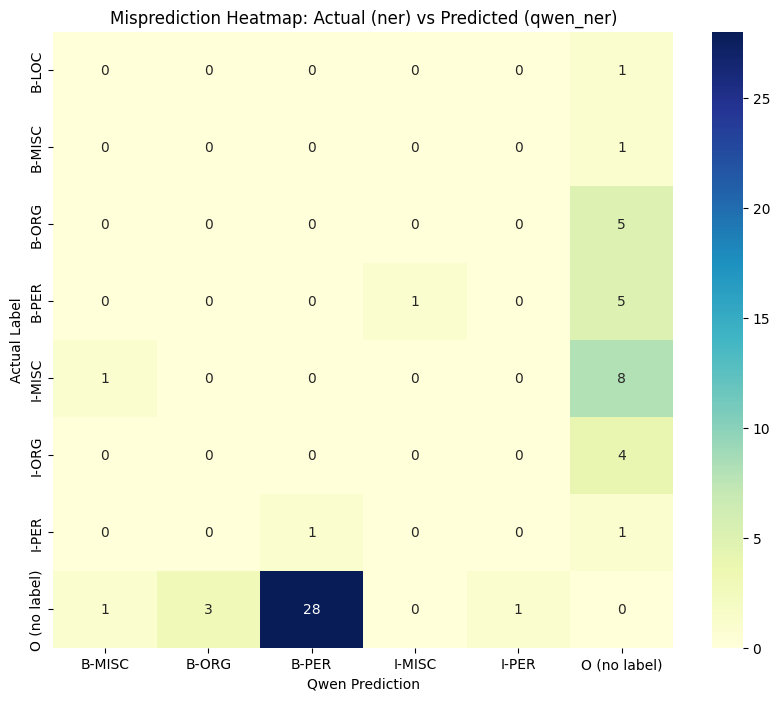

In [133]:
#Mismatched rows CM
cm = pd.crosstab(mismatched_rows['ner'], mismatched_rows['qwen_ner'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Misprediction Heatmap: Actual (ner) vs Predicted (qwen_ner)')
plt.ylabel('Actual Label')
plt.xlabel('Qwen Prediction')
plt.show()

In [134]:
mismatched_rows

,Unnamed: 0.1,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,qwen_ner
32,32,32,post_0001,2,12,yola,TR,NONE,O (no label),B-PER
88,88,88,post_0003,3,7,oyle,TR,NONE,O (no label),B-PER
106,106,106,post_0004,1,2,türkçe,TR,NONE,O (no label),B-MISC
135,135,135,post_0004,2,29,gibi,TR,NONE,O (no label),B-PER
160,160,160,post_0005,2,0,google,OTHER,NONE,O (no label),B-ORG
...,...,...,...,...,...,...,...,...,...,...
1021,1021,1021,post_0036,4,0,fm,EN,NONE,I-ORG,O (no label)
1025,1025,1025,post_0036,5,2,tam,TR,NONE,O (no label),B-PER
1054,1054,1054,post_0038,1,5,diyerek,TR,NONE,O (no label),B-PER
1088,1088,1088,post_0039,5,3,james,OTHER,NONE,I-PER,B-PER
